In [1]:
import pandas as pd
import numpy as np

In [2]:
clients = pd.read_csv(r"C:\Users\user\OneDrive\Desktop\clients.csv")
properties = pd.read_csv(r"C:\Users\user\OneDrive\Desktop\properties.csv")

In [3]:
print("Clients Dataset Shape:", clients.shape)
print("Properties Dataset Shape:", properties.shape)

Clients Dataset Shape: (2000, 12)
Properties Dataset Shape: (10000, 9)


In [4]:
clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [5]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [6]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [7]:
properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  object 
 3   unit_category     10000 non-null  object 
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  object 
 7   listing_status    10000 non-null  object 
 8   client_ref        7305 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.3+ KB


In [8]:
clients.isnull().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

In [9]:
properties.isnull().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [10]:
print("Duplicate Clients:", clients.duplicated().sum())
print("Duplicate Properties:", properties.duplicated().sum())

Duplicate Clients: 0
Duplicate Properties: 0


In [11]:
clients.describe(include='all')
properties.describe(include='all')

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
count,10000.000000,10000.000000,10000,10000,10000.00000,10000.000000,10000,10000,7305
unique,NaN,NaN,24,2,NaN,NaN,9998,2,2000
top,NaN,NaN,06-01-2024,Apartment,NaN,NaN,"$460,001.26",Sold,C0005
freq,NaN,NaN,537,8547,NaN,NaN,2,7305,13
mean,105898.277400,10.370100,NaN,NaN,28.99920,1139.941412,NaN,NaN,NaN
std,74414.566199,5.769025,NaN,NaN,16.88242,418.373967,NaN,NaN,NaN
min,1002.000000,1.000000,NaN,NaN,1.00000,410.710000,NaN,NaN,NaN
25%,50389.750000,5.000000,NaN,NaN,15.00000,782.200000,NaN,NaN,NaN
50%,100404.500000,10.000000,NaN,NaN,29.00000,1110.880000,NaN,NaN,NaN
75%,150411.250000,15.000000,NaN,NaN,43.00000,1499.000000,NaN,NaN,NaN


In [12]:
clients['date_of_birth'] = pd.to_datetime(
    clients['date_of_birth'],
    format='mixed'
)

properties['transaction_date'] = pd.to_datetime(
    properties['transaction_date'],
    format='mixed'
)

In [13]:
clients['date_of_birth'].head()
properties['transaction_date'].head()

0   2024-01-01
1   2024-01-01
2   2024-01-01
3   2024-01-01
4   2024-01-01
Name: transaction_date, dtype: datetime64[ns]

In [14]:
current_year = 2026

clients['Age'] = current_year - clients['date_of_birth'].dt.year

In [15]:
clients[['date_of_birth','Age']].head()

,date_of_birth,Age
0,1968-05-11,58
1,1962-11-26,64
2,1959-04-07,67
3,1959-11-25,67
4,1976-02-28,50


In [16]:
properties['sale_price'] = (
    properties['sale_price']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

In [17]:
properties['sale_price'].dtype

dtype('float64')

In [18]:
properties[
    properties['client_ref'].isnull()
]['listing_status'].value_counts()

listing_status
Available    2695
Name: count, dtype: int64

In [19]:
sold_properties = properties[
    properties['client_ref'].notnull()
].copy()

In [20]:
sold_properties.shape

(7305, 9)

In [21]:
sold_properties.isnull().sum()

listing_id          0
tower_number        0
transaction_date    0
unit_category       0
unit_number         0
floor_area_sqft     0
sale_price          0
listing_status      0
client_ref          0
dtype: int64

In [22]:
clients.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel', 'Age'],
      dtype='object')

In [23]:
sold_properties.columns

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref'],
      dtype='object')

In [24]:
merged_df = pd.merge(
    clients,
    sold_properties,
    left_on='client_id',
    right_on='client_ref',
    how='inner'
)

In [25]:
merged_df.shape

(7305, 22)

In [26]:
merged_df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,Age,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,58,90343,9,2024-10-01,Apartment,40,1090.32,351419.29,Sold,C0001
1,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,58,4051,4,2024-12-01,Apartment,51,1608.84,496266.41,Sold,C0001
2,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,58,150099,15,2025-05-01,Apartment,15,522.71,175599.90,Sold,C0001
3,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,58,30432,3,2025-12-01,Apartment,50,713.67,223479.12,Sold,C0001
4,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,...,64,150044,15,2024-01-01,Apartment,6,938.57,299245.20,Sold,C0002


In [27]:
merged_df.isnull().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
Age                    0
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref             0
dtype: int64

In [28]:
merged_df.duplicated().sum()

np.int64(0)

In [29]:
merged_df['client_id'].value_counts().head()

client_id
C0005    13
C0007    11
C0026    10
C0050     9
C0102     9
Name: count, dtype: int64

In [30]:
purchase_count = (
    merged_df.groupby('client_id')
    .size()
    .reset_index(name='properties_owned')
)

In [31]:
purchase_count.head()

,client_id,properties_owned
0,C0001,4
1,C0002,5
2,C0003,5
3,C0004,6
4,C0005,13


In [32]:
merged_df.drop('client_ref', axis=1, inplace=True)

In [33]:
merged_df.shape

(7305, 21)

In [34]:
merged_df = pd.merge(
    merged_df,
    purchase_count,
    on='client_id',
    how='left'
)

In [35]:
merged_df[['client_id','properties_owned']].head()

,client_id,properties_owned
0,C0001,4
1,C0001,4
2,C0001,4
3,C0001,4
4,C0002,5


In [36]:
total_investment = (
    merged_df.groupby('client_id')['sale_price']
    .sum()
    .reset_index(name='total_investment')
)

In [37]:
total_investment.head()

,client_id,total_investment
0,C0001,1246764.72
1,C0002,1841095.93
2,C0003,1661457.59
3,C0004,1608263.51
4,C0005,3653385.38


In [38]:
avg_area = (
    merged_df.groupby('client_id')['floor_area_sqft']
    .mean()
    .reset_index(name='avg_floor_area')
)

In [39]:
avg_area.head()

,client_id,avg_floor_area
0,C0001,983.885000
1,C0002,1187.942000
2,C0003,1058.110000
3,C0004,937.103333
4,C0005,927.296154


In [40]:
avg_satisfaction = (
    merged_df.groupby('client_id')['satisfaction_score']
    .mean()
    .reset_index(name='avg_satisfaction')
)

In [41]:
avg_satisfaction.head()

,client_id,avg_satisfaction
0,C0001,4.0
1,C0002,1.0
2,C0003,4.0
3,C0004,5.0
4,C0005,5.0


In [42]:
buyer_df = merged_df.groupby('client_id').agg({
    'Age':'first',
    'gender':'first',
    'country':'first',
    'region':'first',
    'client_type':'first',
    'acquisition_purpose':'first',
    'loan_applied':'first',
    'referral_channel':'first',
    'properties_owned':'first'
}).reset_index()

In [43]:
buyer_df.head()

,client_id,Age,gender,country,region,client_type,acquisition_purpose,loan_applied,referral_channel,properties_owned
0,C0001,58,F,USA,California,Individual,Home,Yes,Website,4
1,C0002,64,M,USA,California,Individual,Home,No,Website,5
2,C0003,67,M,USA,California,Individual,Home,Yes,Agency,5
3,C0004,67,M,USA,California,Individual,Home,No,Website,6
4,C0005,50,M,USA,California,Company,Investment,No,Website,13


In [44]:
buyer_df = pd.merge(
    buyer_df,
    total_investment,
    on='client_id'
)

In [45]:
buyer_df = pd.merge(
    buyer_df,
    avg_area,
    on='client_id'
)

In [46]:
buyer_df = pd.merge(
    buyer_df,
    avg_satisfaction,
    on='client_id'
)

In [47]:
buyer_df.shape

(2000, 13)

In [48]:
total_investment = (
    merged_df.groupby('client_id')['sale_price']
    .sum()
    .reset_index(name='total_investment')
)

total_investment.head()

,client_id,total_investment
0,C0001,1246764.72
1,C0002,1841095.93
2,C0003,1661457.59
3,C0004,1608263.51
4,C0005,3653385.38


In [49]:
avg_area = (
    merged_df.groupby('client_id')['floor_area_sqft']
    .mean()
    .reset_index(name='avg_floor_area')
)

avg_area.head()

,client_id,avg_floor_area
0,C0001,983.885000
1,C0002,1187.942000
2,C0003,1058.110000
3,C0004,937.103333
4,C0005,927.296154


In [50]:
avg_satisfaction = (
    merged_df.groupby('client_id')['satisfaction_score']
    .mean()
    .reset_index(name='avg_satisfaction')
)

avg_satisfaction.head()

,client_id,avg_satisfaction
0,C0001,4.0
1,C0002,1.0
2,C0003,4.0
3,C0004,5.0
4,C0005,5.0


In [51]:
buyer_df = merged_df.groupby('client_id').agg({
    'Age':'first',
    'gender':'first',
    'country':'first',
    'region':'first',
    'client_type':'first',
    'acquisition_purpose':'first',
    'loan_applied':'first',
    'referral_channel':'first',
    'properties_owned':'first'
}).reset_index()

buyer_df.head()

,client_id,Age,gender,country,region,client_type,acquisition_purpose,loan_applied,referral_channel,properties_owned
0,C0001,58,F,USA,California,Individual,Home,Yes,Website,4
1,C0002,64,M,USA,California,Individual,Home,No,Website,5
2,C0003,67,M,USA,California,Individual,Home,Yes,Agency,5
3,C0004,67,M,USA,California,Individual,Home,No,Website,6
4,C0005,50,M,USA,California,Company,Investment,No,Website,13


In [52]:
buyer_df.shape

(2000, 10)

In [53]:
buyer_df = pd.merge(
    buyer_df,
    total_investment,
    on='client_id',
    how='left'
)

In [54]:
buyer_df = pd.merge(
    buyer_df,
    avg_area,
    on='client_id',
    how='left'
)

In [55]:
buyer_df = pd.merge(
    buyer_df,
    avg_satisfaction,
    on='client_id',
    how='left'
)

In [56]:
buyer_df.head()

,client_id,Age,gender,country,region,client_type,acquisition_purpose,loan_applied,referral_channel,properties_owned,total_investment,avg_floor_area,avg_satisfaction
0,C0001,58,F,USA,California,Individual,Home,Yes,Website,4,1246764.72,983.885000,4.0
1,C0002,64,M,USA,California,Individual,Home,No,Website,5,1841095.93,1187.942000,1.0
2,C0003,67,M,USA,California,Individual,Home,Yes,Agency,5,1661457.59,1058.110000,4.0
3,C0004,67,M,USA,California,Individual,Home,No,Website,6,1608263.51,937.103333,5.0
4,C0005,50,M,USA,California,Company,Investment,No,Website,13,3653385.38,927.296154,5.0


In [57]:
buyer_df.shape

(2000, 13)

In [58]:
buyer_df.isnull().sum()

client_id              0
Age                    0
gender                 0
country                0
region                 0
client_type            0
acquisition_purpose    0
loan_applied           0
referral_channel       0
properties_owned       0
total_investment       0
avg_floor_area         0
avg_satisfaction       0
dtype: int64

In [59]:
buyer_df.describe()

,Age,properties_owned,total_investment,avg_floor_area,avg_satisfaction
count,2000.000000,2000.0000,2.000000e+03,2000.000000,2000.000000
mean,56.099000,3.6525,1.260375e+06,1147.479668,3.029000
std,17.343719,0.8397,3.478307e+05,219.922587,1.413562
min,26.000000,3.0000,4.636120e+05,564.010000,1.000000
25%,41.000000,3.0000,1.025238e+06,984.952500,2.000000
50%,57.000000,4.0000,1.220893e+06,1129.176667,3.000000
75%,71.000000,4.0000,1.441974e+06,1296.562500,4.000000
max,95.000000,13.0000,3.653385e+06,1800.450000,5.000000


In [60]:
buyer_df['client_type'].value_counts()

client_type
Individual    1897
Company        103
Name: count, dtype: int64

In [61]:
buyer_df['acquisition_purpose'].value_counts()

acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64

In [62]:
buyer_df['loan_applied'].value_counts()

loan_applied
No     1264
Yes     736
Name: count, dtype: int64

In [63]:
buyer_df['region'].value_counts()

region
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Ohio                       24
Northern Ireland           24
British Columbia           20
Wales                      17
Brittany                   16
Flanders                   16
Hamburg                    16
Wallonia                   15
Ile-de-France              15
Manitoba                   15
Quebec                     14
New South Wales            13
Victoria                   13
Bavaria                    12
Brussels                   12
Berlin                     11
Nuevo Leon                 10
Provence                   10
Nor

In [64]:
buyer_df['country'].value_counts()

country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

In [65]:
buyer_df['gender'].value_counts()

gender
M    1012
F     988
Name: count, dtype: int64

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

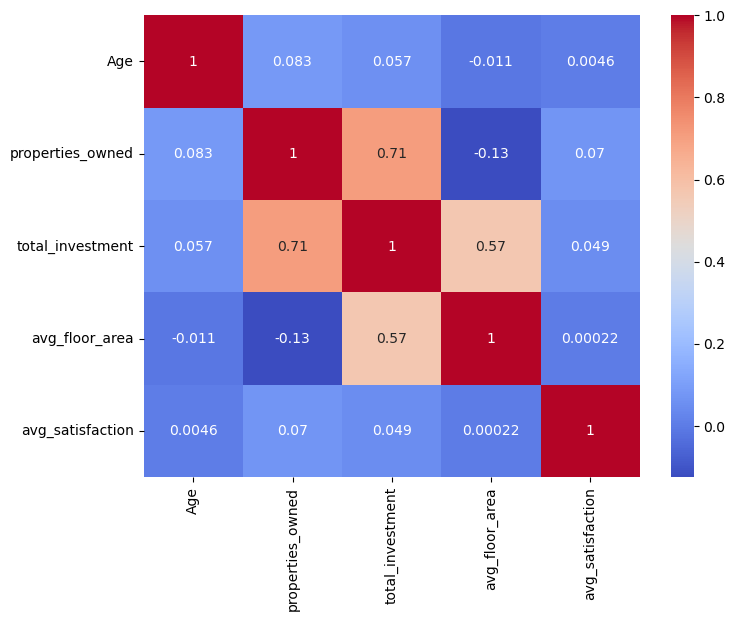

In [67]:
numeric_cols = [
    'Age',
    'properties_owned',
    'total_investment',
    'avg_floor_area',
    'avg_satisfaction'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    buyer_df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

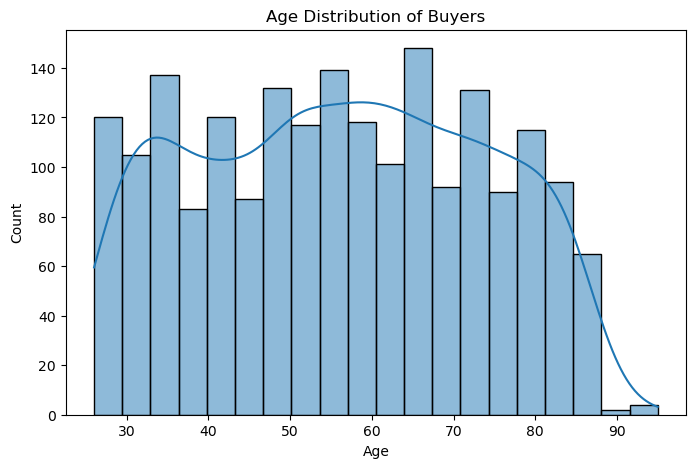

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(
    buyer_df['Age'],
    bins=20,
    kde=True
)

plt.title('Age Distribution of Buyers')

plt.show()

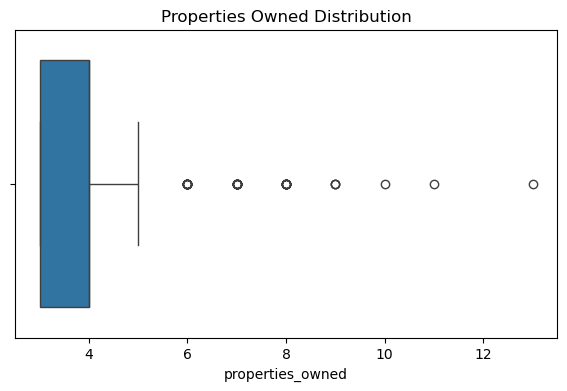

In [69]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x=buyer_df['properties_owned']
)

plt.title('Properties Owned Distribution')

plt.show()

In [70]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


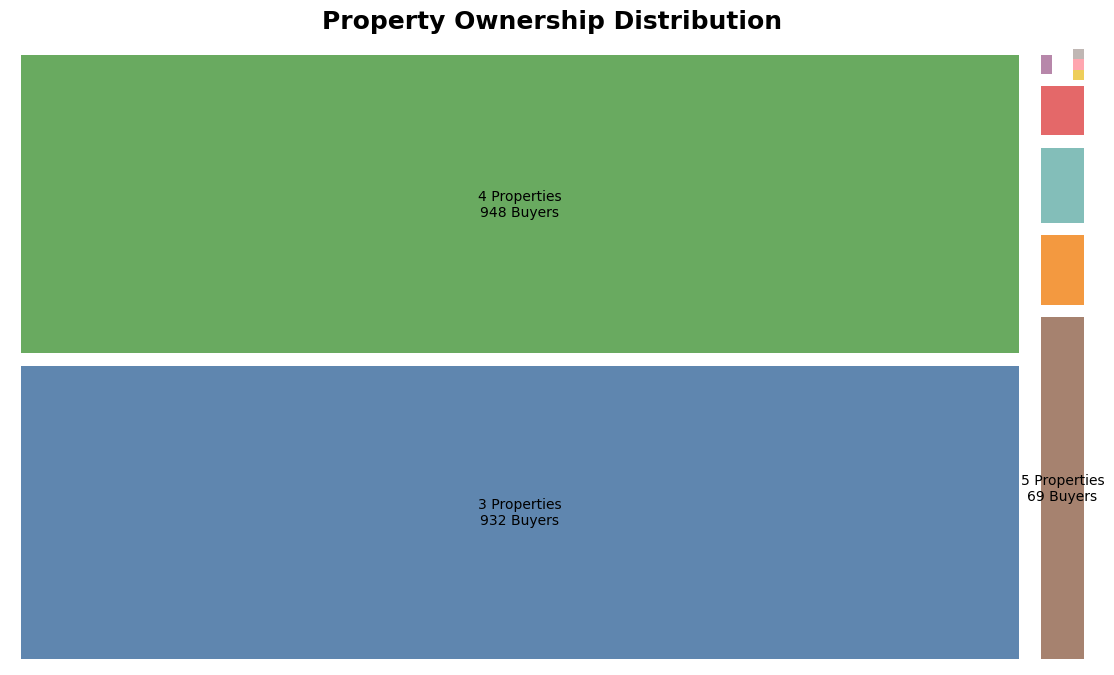

In [71]:
import squarify
import matplotlib.pyplot as plt

property_counts = (
    buyer_df['properties_owned']
    .value_counts()
    .sort_index()
)

# Show labels only for categories with at least 50 buyers
labels = []

for prop, count in zip(property_counts.index, property_counts.values):
    if count >= 50:
        labels.append(f"{prop} Properties\n{count} Buyers")
    else:
        labels.append("")

colors = [
    "#4E79A7",
    "#59A14F",
    "#9C755F",
    "#F28E2B",
    "#76B7B2",
    "#E15759",
    "#B07AA1",
    "#EDC948",
    "#FF9DA7",
    "#BAB0AC",
    "#86BCB6"
]

plt.figure(figsize=(14,8))

squarify.plot(
    sizes=property_counts.values,
    label=labels,
    color=colors[:len(property_counts)],
    alpha=0.9,
    pad=True
)

plt.axis("off")

plt.title(
    "Property Ownership Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.show()

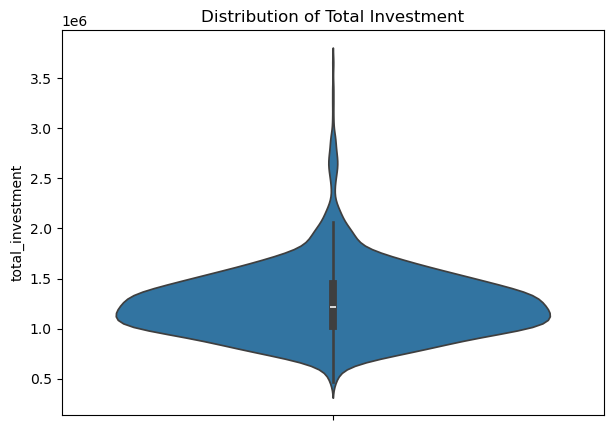

In [72]:
plt.figure(figsize=(7,5))

sns.violinplot(
    y=buyer_df['total_investment']
)

plt.title('Distribution of Total Investment')

plt.show()

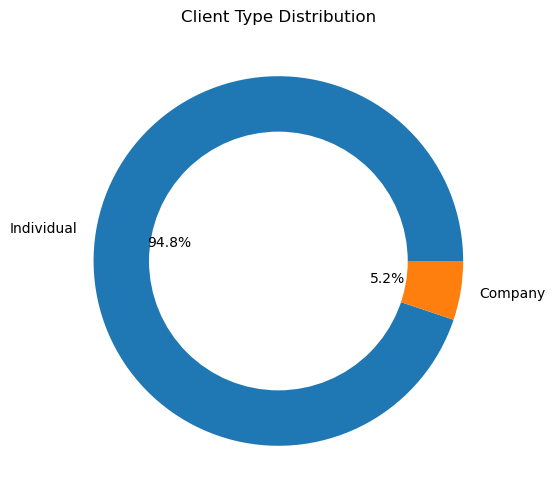

In [73]:
client_counts = buyer_df['client_type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    client_counts,
    labels=client_counts.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title('Client Type Distribution')

plt.show()

In [74]:
pip install pywaffle

Note: you may need to restart the kernel to use updated packages.


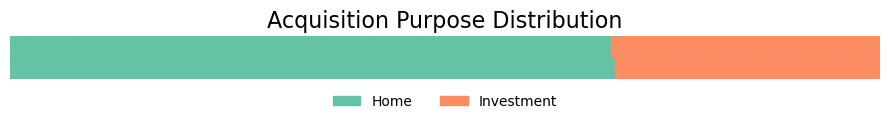

In [75]:
from pywaffle import Waffle
import matplotlib.pyplot as plt

purpose_counts = buyer_df['acquisition_purpose'].value_counts()

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    values=purpose_counts.to_dict(),
    figsize=(9,5),
    title={
        'label':'Acquisition Purpose Distribution',
        'loc':'center',
        'fontsize':16
    },
    legend={
        'loc':'upper center',
        'bbox_to_anchor':(0.5, -0.08),   # Moves legend below the chart
        'ncol':2,                        # Home and Investment side by side
        'frameon':False                  # Removes legend box
    }
)

plt.tight_layout()
plt.show()

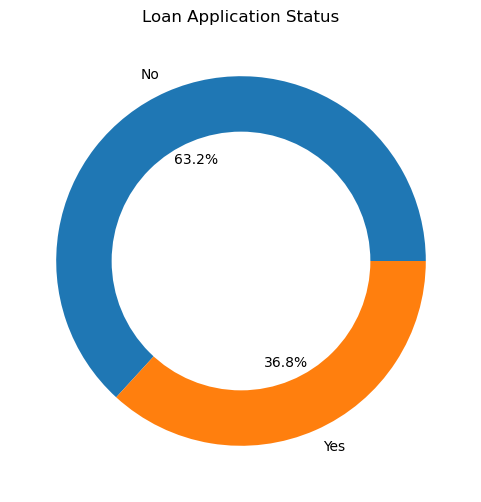

In [76]:
loan_counts = buyer_df['loan_applied'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    loan_counts,
    labels=loan_counts.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title('Loan Application Status')

plt.show()

In [77]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


<Figure size 1000x600 with 0 Axes>

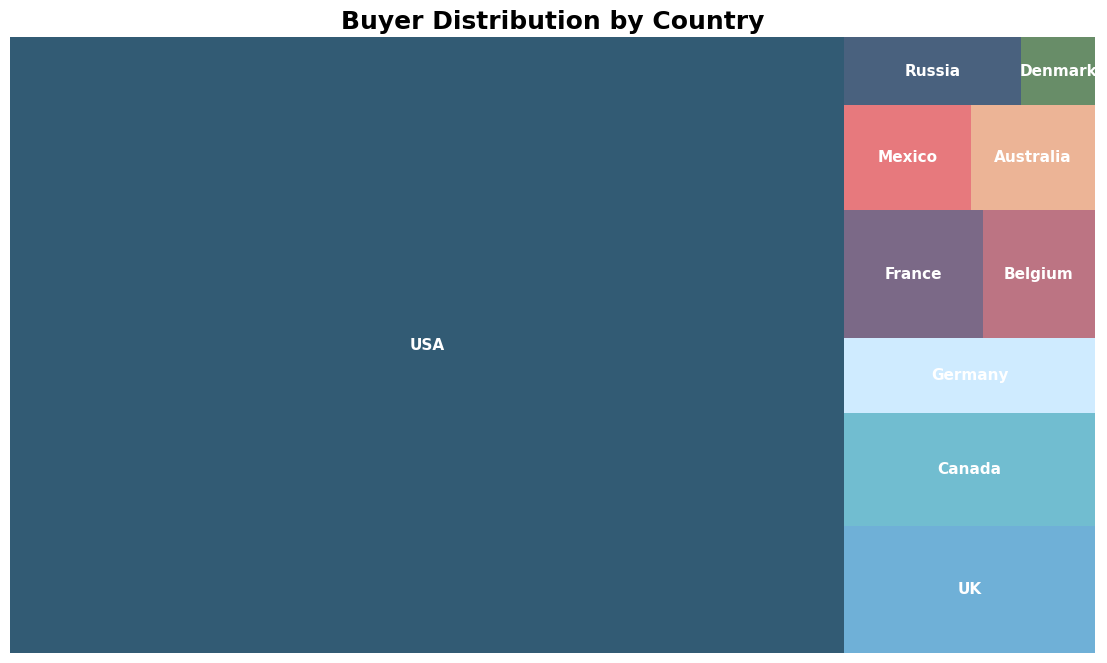

In [78]:
import squarify

country_counts = buyer_df['country'].value_counts()

plt.figure(figsize=(10,6))

colors = [
    "#1B4965",
    "#5FA8D3",
    "#62B6CB",
    "#CAE9FF",
    "#6D597A",
    "#B56576",
    "#E56B6F",
    "#EAAC8B",
    "#355070",
    "#588157"
]

plt.figure(figsize=(14,8))

squarify.plot(
    sizes=country_counts.values,
    label=country_counts.index,
    color=colors[:len(country_counts)],
    alpha=0.9,
    pad=False,
    text_kwargs={
        'fontsize':11,
        'fontweight':'bold',
        'color':'white'
    }
)

plt.axis('off')

plt.title(
    'Buyer Distribution by Country',
    fontsize=18,
    fontweight='bold',
)

plt.show()

In [79]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [80]:
import plotly.express as px

region_data = (
    buyer_df.groupby(['country', 'region'])
    .size()
    .reset_index(name='buyers')
)

fig = px.sunburst(
    region_data,
    path=['country', 'region'],
    values='buyers',
    color='country',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    width=800,
    height=900,
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=14)
)

fig.show()

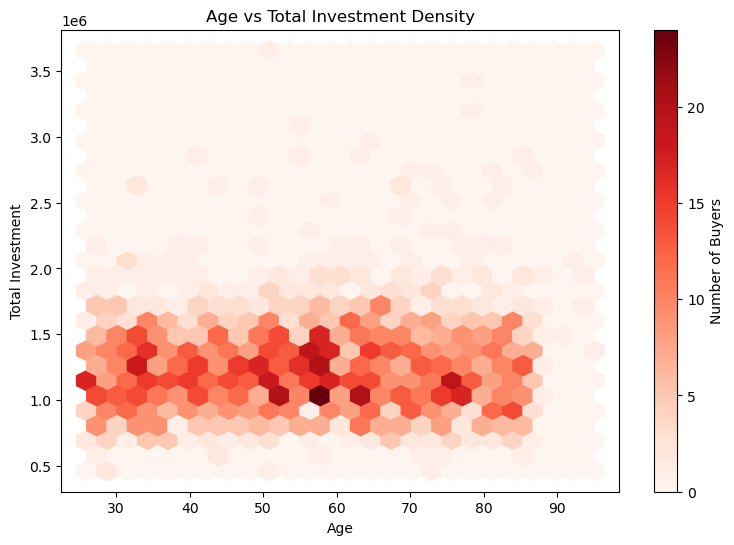

In [81]:
plt.figure(figsize=(9,6))

plt.hexbin(
    buyer_df['Age'],
    buyer_df['total_investment'],
    gridsize=25,
    cmap='Reds'
)

plt.colorbar(label='Number of Buyers')

plt.xlabel('Age')

plt.ylabel('Total Investment')

plt.title('Age vs Total Investment Density')

plt.show()

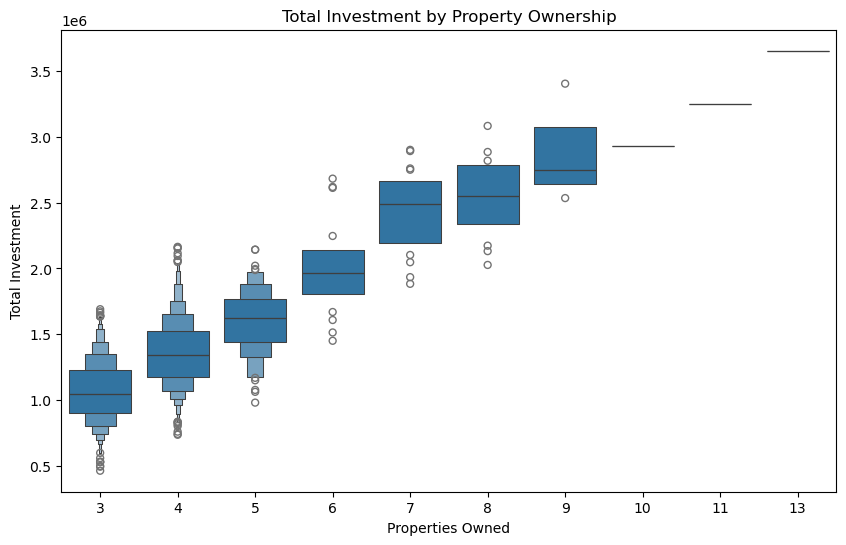

In [82]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    data=buyer_df,
    x='properties_owned',
    y='total_investment'
)

plt.title('Total Investment by Property Ownership')
plt.xlabel('Properties Owned')
plt.ylabel('Total Investment')

plt.show()

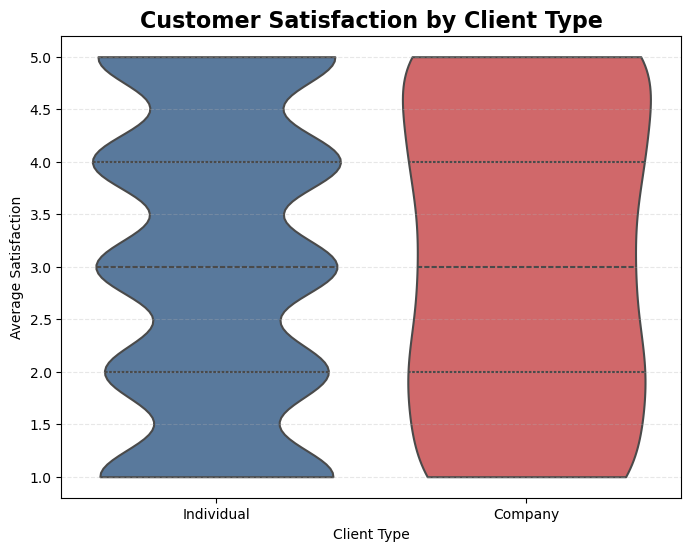

In [83]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=buyer_df,
    x='client_type',
    y='avg_satisfaction',
    hue='client_type',
    palette=['#4E79A7', '#E15759'],
    inner='quartile',
    linewidth=1.5,
    cut=0,
    legend=False
)

plt.title(
    'Customer Satisfaction by Client Type',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Client Type')
plt.ylabel('Average Satisfaction')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [84]:
# Select features for clustering

ml_df = buyer_df[[
    'Age',
    'gender',
    'country',
    'region',
    'client_type',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel',
    'properties_owned',
    'total_investment',
    'avg_floor_area'
]]

ml_df.head()

,Age,gender,country,region,client_type,acquisition_purpose,loan_applied,referral_channel,properties_owned,total_investment,avg_floor_area
0,58,F,USA,California,Individual,Home,Yes,Website,4,1246764.72,983.885000
1,64,M,USA,California,Individual,Home,No,Website,5,1841095.93,1187.942000
2,67,M,USA,California,Individual,Home,Yes,Agency,5,1661457.59,1058.110000
3,67,M,USA,California,Individual,Home,No,Website,6,1608263.51,937.103333
4,50,M,USA,California,Company,Investment,No,Website,13,3653385.38,927.296154


In [85]:
ml_df.shape

(2000, 11)

In [86]:
ml_df.isnull().sum()

Age                    0
gender                 0
country                0
region                 0
client_type            0
acquisition_purpose    0
loan_applied           0
referral_channel       0
properties_owned       0
total_investment       0
avg_floor_area         0
dtype: int64

In [87]:
ml_encoded = ml_df.copy()

In [88]:
from sklearn.preprocessing import LabelEncoder

In [89]:
label_cols = [
    'gender',
    'client_type',
    'acquisition_purpose',
    'loan_applied'
]

le = LabelEncoder()

for col in label_cols:
    ml_encoded[col] = le.fit_transform(ml_encoded[col])

In [90]:
ml_final = pd.get_dummies(
    ml_encoded,
    columns=[
        'country',
        'region',
        'referral_channel'
    ],
    drop_first=False,
    dtype=int
)

In [91]:
ml_final.head()

,Age,gender,client_type,acquisition_purpose,loan_applied,properties_owned,total_investment,avg_floor_area,country_Australia,country_Belgium,...,region_Virginia,region_Wales,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,referral_channel_Agency,referral_channel_Client,referral_channel_Website
0,58,0,1,0,1,4,1246764.72,983.885000,0,0,...,0,0,0,0,0,0,0,0,0,1
1,64,1,1,0,0,5,1841095.93,1187.942000,0,0,...,0,0,0,0,0,0,0,0,0,1
2,67,1,1,0,1,5,1661457.59,1058.110000,0,0,...,0,0,0,0,0,0,0,1,0,0
3,67,1,1,0,0,6,1608263.51,937.103333,0,0,...,0,0,0,0,0,0,0,0,0,1
4,50,1,0,1,0,13,3653385.38,927.296154,0,0,...,0,0,0,0,0,0,0,0,0,1


In [92]:
ml_final.shape

(2000, 78)

In [93]:
ml_final.dtypes.value_counts()

int64      75
float64     2
int32       1
Name: count, dtype: int64

In [94]:
from sklearn.preprocessing import StandardScaler

In [95]:
ml_scaled = ml_final.copy()

In [96]:
scaler = StandardScaler()

In [97]:
ml_scaled = pd.DataFrame(
    scaler.fit_transform(ml_scaled),
    columns=ml_final.columns
)

In [98]:
ml_scaled.shape

(2000, 78)

In [99]:
ml_scaled.head()

,Age,gender,client_type,acquisition_purpose,loan_applied,properties_owned,total_investment,avg_floor_area,country_Australia,country_Belgium,...,region_Virginia,region_Wales,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,referral_channel_Agency,referral_channel_Client,referral_channel_Website
0,0.109635,-1.012073,0.233016,-0.666366,1.310493,0.413942,-0.039140,-0.744060,-0.141024,-0.148231,...,-0.18328,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,-0.737836,-0.325875,0.901796
1,0.455668,0.988071,0.233016,-0.666366,-0.763072,1.605141,1.669967,0.184030,-0.141024,-0.148231,...,-0.18328,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,-0.737836,-0.325875,0.901796
2,0.628684,0.988071,0.233016,-0.666366,1.310493,1.605141,1.153384,-0.406470,-0.141024,-0.148231,...,-0.18328,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,1.355315,-0.325875,-1.108898
3,0.628684,0.988071,0.233016,-0.666366,-0.763072,2.796340,1.000415,-0.956832,-0.141024,-0.148231,...,-0.18328,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,-0.737836,-0.325875,0.901796
4,-0.351743,0.988071,-4.291559,1.500677,-0.763072,11.134734,6.881534,-1.001437,-0.141024,-0.148231,...,-0.18328,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,-0.737836,-0.325875,0.901796


In [100]:
ml_scaled.describe().round(2)

,Age,gender,client_type,acquisition_purpose,loan_applied,properties_owned,total_investment,avg_floor_area,country_Australia,country_Belgium,...,region_Virginia,region_Wales,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,referral_channel_Agency,referral_channel_Client,referral_channel_Website
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,...,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,...,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.74,-1.01,-4.29,-0.67,-0.76,-0.78,-2.29,-2.65,-0.14,-0.15,...,-0.18,-0.09,-0.09,-0.19,-0.05,-0.02,-0.03,-0.74,-0.33,-1.11
25%,-0.87,-1.01,0.23,-0.67,-0.76,-0.78,-0.68,-0.74,-0.14,-0.15,...,-0.18,-0.09,-0.09,-0.19,-0.05,-0.02,-0.03,-0.74,-0.33,-1.11
50%,0.05,0.99,0.23,-0.67,-0.76,0.41,-0.11,-0.08,-0.14,-0.15,...,-0.18,-0.09,-0.09,-0.19,-0.05,-0.02,-0.03,-0.74,-0.33,0.90
75%,0.86,0.99,0.23,1.50,1.31,0.41,0.52,0.68,-0.14,-0.15,...,-0.18,-0.09,-0.09,-0.19,-0.05,-0.02,-0.03,1.36,-0.33,0.90
max,2.24,0.99,0.23,1.50,1.31,11.13,6.88,2.97,7.09,6.75,...,5.46,10.80,11.50,5.14,18.23,44.71,31.61,1.36,3.07,0.90


In [101]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [102]:
wcss = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(ml_scaled)

    wcss.append(kmeans.inertia_)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

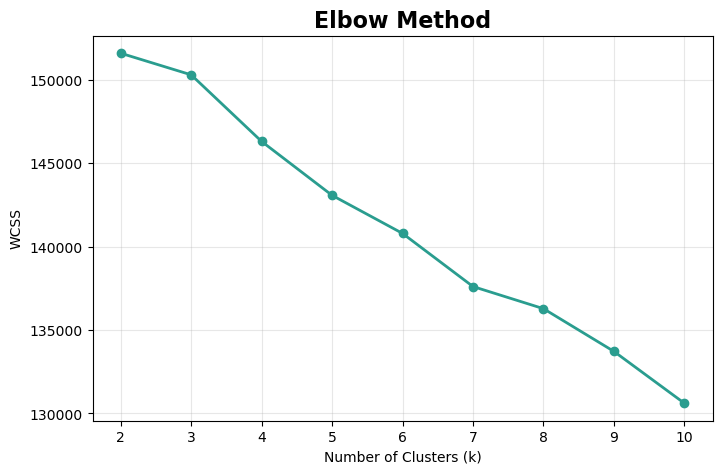

In [103]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o',
    linewidth=2,
    color='#2A9D8F'
)

plt.title(
    'Elbow Method',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')

plt.grid(alpha=0.3)

plt.show()

In [104]:
silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(ml_scaled)

    score = silhouette_score(
        ml_scaled,
        labels
    )

    silhouette_scores.append(score)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

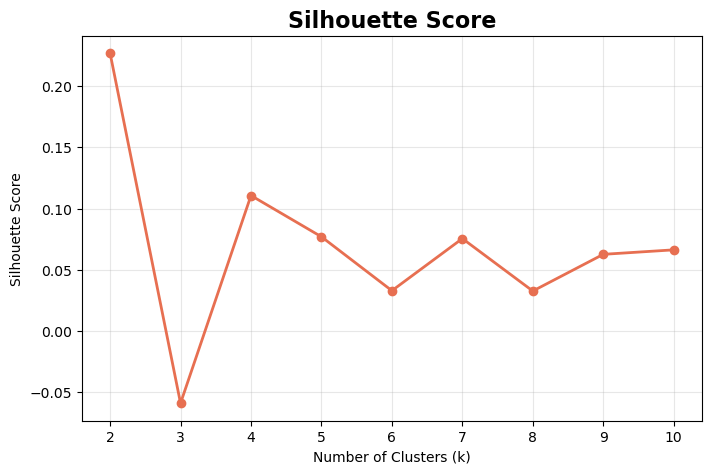

In [105]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o',
    linewidth=2,
    color='#E76F51'
)

plt.title(
    'Silhouette Score',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.grid(alpha=0.3)

plt.show()

In [106]:
for k, score in zip(range(2,11), silhouette_scores):
    print(f'Clusters = {k}  --->  Silhouette Score = {score:.4f}')

Clusters = 2  --->  Silhouette Score = 0.2269
Clusters = 3  --->  Silhouette Score = -0.0590
Clusters = 4  --->  Silhouette Score = 0.1107
Clusters = 5  --->  Silhouette Score = 0.0770
Clusters = 6  --->  Silhouette Score = 0.0329
Clusters = 7  --->  Silhouette Score = 0.0755
Clusters = 8  --->  Silhouette Score = 0.0326
Clusters = 9  --->  Silhouette Score = 0.0626
Clusters = 10  --->  Silhouette Score = 0.0663


In [107]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(ml_scaled)


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.



In [108]:
buyer_clustered = buyer_df.copy()

buyer_clustered['Cluster'] = cluster_labels

In [109]:
buyer_clustered['Cluster'].value_counts().sort_index()

Cluster
0      49
1     419
2      50
3    1482
Name: count, dtype: int64

In [110]:
(
buyer_clustered['Cluster']
.value_counts(normalize=True)
.mul(100)
.round(2)
.sort_index()
)

Cluster
0     2.45
1    20.95
2     2.50
3    74.10
Name: proportion, dtype: float64

In [111]:
buyer_clustered.head()

,client_id,Age,gender,country,region,client_type,acquisition_purpose,loan_applied,referral_channel,properties_owned,total_investment,avg_floor_area,avg_satisfaction,Cluster
0,C0001,58,F,USA,California,Individual,Home,Yes,Website,4,1246764.72,983.885000,4.0,3
1,C0002,64,M,USA,California,Individual,Home,No,Website,5,1841095.93,1187.942000,1.0,3
2,C0003,67,M,USA,California,Individual,Home,Yes,Agency,5,1661457.59,1058.110000,4.0,3
3,C0004,67,M,USA,California,Individual,Home,No,Website,6,1608263.51,937.103333,5.0,3
4,C0005,50,M,USA,California,Company,Investment,No,Website,13,3653385.38,927.296154,5.0,3


In [112]:
for k in [4, 5, 6]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(ml_scaled)

    print(f"\n{k} Clusters")
    print(pd.Series(labels).value_counts().sort_index())

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.




4 Clusters
0      49
1     419
2      50
3    1482
Name: count, dtype: int64


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.




5 Clusters
0     413
1      65
2      13
3    1499
4      10
Name: count, dtype: int64


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.




6 Clusters
0    1485
1      96
2      20
3      13
4       8
5     378
Name: count, dtype: int64


In [113]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

In [114]:
linked = linkage(
    ml_scaled,
    method='ward'
)

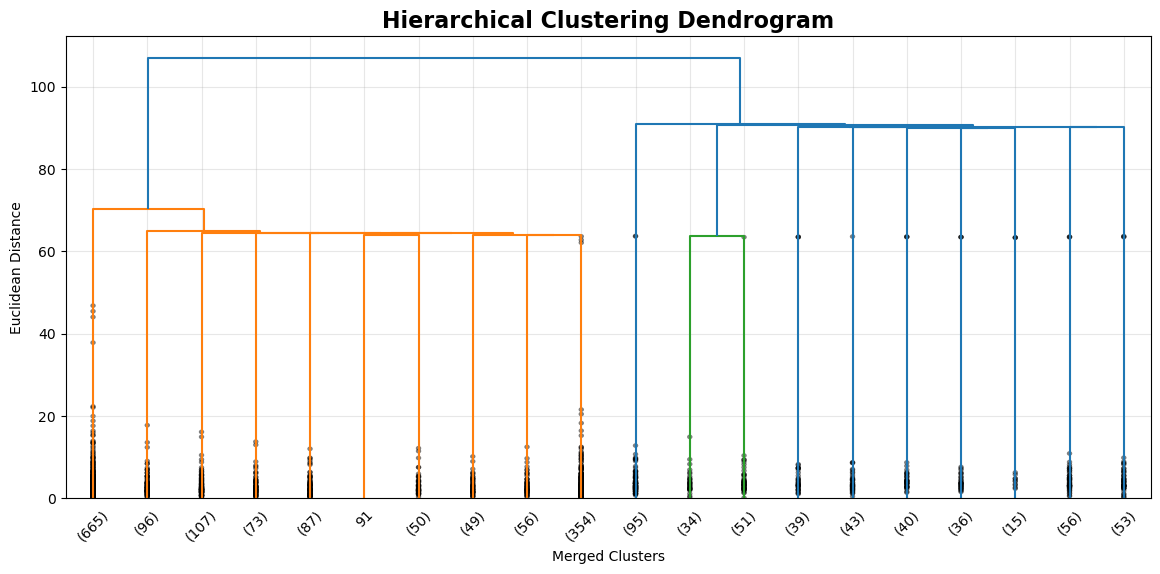

In [115]:
plt.figure(figsize=(14,6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)

plt.title(
    'Hierarchical Clustering Dendrogram',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Merged Clusters")
plt.ylabel("Euclidean Distance")

plt.grid(alpha=0.3)

plt.show()

In [116]:
agg = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

agg_labels = agg.fit_predict(ml_scaled)

In [117]:
buyer_hierarchical = buyer_df.copy()

buyer_hierarchical["Cluster"] = agg_labels

In [118]:
buyer_hierarchical["Cluster"].value_counts().sort_index()

Cluster
0     282
1    1538
2      95
3      85
Name: count, dtype: int64

In [119]:
(
buyer_hierarchical["Cluster"]
.value_counts(normalize=True)
.mul(100)
.round(2)
.sort_index()
)

Cluster
0    14.10
1    76.90
2     4.75
3     4.25
Name: proportion, dtype: float64

In [120]:
cluster_summary = buyer_clustered.groupby("Cluster")[[
    "Age",
    "properties_owned",
    "total_investment",
    "avg_floor_area",
    "avg_satisfaction"
]].mean().round(2)

cluster_summary

,Age,properties_owned,total_investment,avg_floor_area,avg_satisfaction
Cluster,,,,,
0,59.20,3.45,1246612.74,1188.14,3.04
1,54.70,3.55,1225519.28,1148.38,3.03
2,51.88,3.72,1333435.16,1188.05,2.92
3,56.54,3.69,1268220.38,1144.51,3.03


In [121]:
loan_summary = pd.crosstab(
    buyer_clustered["Cluster"],
    buyer_clustered["loan_applied"],
    normalize="index"
).round(3) * 100

loan_summary

loan_applied,No,Yes
Cluster,,
0,63.3,36.7
1,61.1,38.9
2,70.0,30.0
3,63.6,36.4


In [122]:
client_summary = pd.crosstab(
    buyer_clustered["Cluster"],
    buyer_clustered["client_type"],
    normalize="index"
).round(3) * 100

client_summary

client_type,Company,Individual
Cluster,,
0,2.0,98.0
1,5.3,94.7
2,4.0,96.0
3,5.3,94.7


In [123]:
purpose_summary = pd.crosstab(
    buyer_clustered["Cluster"],
    buyer_clustered["acquisition_purpose"],
    normalize="index"
).round(3) * 100

purpose_summary

acquisition_purpose,Home,Investment
Cluster,,
0,79.6,20.4
1,69.2,30.8
2,86.0,14.0
3,68.4,31.6


In [124]:
referral_summary = pd.crosstab(
    buyer_clustered["Cluster"],
    buyer_clustered["referral_channel"],
    normalize="index"
).round(3) * 100

referral_summary

referral_channel,Agency,Client,Website
Cluster,,,
0,28.6,6.1,65.3
1,33.2,9.8,57.0
2,34.0,12.0,54.0
3,36.1,9.6,54.3


In [125]:
country_summary = (
    buyer_clustered
    .groupby("Cluster")["country"]
    .agg(lambda x: x.value_counts().idxmax())
)

country_summary

Cluster
0    USA
1     UK
2    USA
3    USA
Name: country, dtype: object

In [126]:
region_summary = (
    buyer_clustered
    .groupby("Cluster")["region"]
    .agg(lambda x: x.value_counts().idxmax())
)

region_summary

Cluster
0      New York
1       England
2       Florida
3    California
Name: region, dtype: object

In [127]:
segment_mapping = {
    0: "Stable Home Buyers",
    1: "International Diversified Buyers",
    2: "Premium Independent Buyers",
    3: "Growth-Oriented Investors"
}

buyer_clustered["Buyer_Segment"] = buyer_clustered["Cluster"].map(segment_mapping)

In [128]:
buyer_clustered[["client_id", "Cluster", "Buyer_Segment"]].head()

,client_id,Cluster,Buyer_Segment
0,C0001,3,Growth-Oriented Investors
1,C0002,3,Growth-Oriented Investors
2,C0003,3,Growth-Oriented Investors
3,C0004,3,Growth-Oriented Investors
4,C0005,3,Growth-Oriented Investors


In [129]:
def recommend_segment(segment):

    recommendations = {

        "Stable Home Buyers":
        "Recommend residential apartments, family villas, loyalty rewards, and simplified online booking services.",

        "International Diversified Buyers":
        "Offer mortgage assistance, virtual property tours, overseas investment support, and flexible payment options.",

        "Premium Independent Buyers":
        "Recommend luxury residences, VIP investment consultations, premium memberships, and exclusive project launches.",

        "Growth-Oriented Investors":
        "Recommend commercial properties, portfolio diversification opportunities, rental yield analysis, and investment seminars."

    }

    return recommendations.get(segment)

In [130]:
buyer_clustered["Recommendation"] = buyer_clustered["Buyer_Segment"].apply(recommend_segment)

In [131]:
buyer_clustered[[
    "client_id",
    "Buyer_Segment",
    "Recommendation"
]].head()

,client_id,Buyer_Segment,Recommendation
0,C0001,Growth-Oriented Investors,"Recommend commercial properties, portfolio div..."
1,C0002,Growth-Oriented Investors,"Recommend commercial properties, portfolio div..."
2,C0003,Growth-Oriented Investors,"Recommend commercial properties, portfolio div..."
3,C0004,Growth-Oriented Investors,"Recommend commercial properties, portfolio div..."
4,C0005,Growth-Oriented Investors,"Recommend commercial properties, portfolio div..."


In [132]:
buyer_clustered["Investment_Risk"] = pd.qcut(
    buyer_clustered["total_investment"],
    q=3,
    labels=[
        "Low Investment",
        "Medium Investment",
        "High Investment"
    ]
)

In [133]:
buyer_clustered[[
    "client_id",
    "Buyer_Segment",
    "Investment_Risk",
    "Recommendation"
]].head()

,client_id,Buyer_Segment,Investment_Risk,Recommendation
0,C0001,Growth-Oriented Investors,Medium Investment,"Recommend commercial properties, portfolio div..."
1,C0002,Growth-Oriented Investors,High Investment,"Recommend commercial properties, portfolio div..."
2,C0003,Growth-Oriented Investors,High Investment,"Recommend commercial properties, portfolio div..."
3,C0004,Growth-Oriented Investors,High Investment,"Recommend commercial properties, portfolio div..."
4,C0005,Growth-Oriented Investors,High Investment,"Recommend commercial properties, portfolio div..."


In [134]:
investment_profile = buyer_clustered.groupby("Buyer_Segment")[[
    "Age",
    "properties_owned",
    "total_investment",
    "avg_floor_area",
    "avg_satisfaction"
]].agg({
    "Age": "mean",
    "properties_owned": "mean",
    "total_investment": ["mean", "max", "min"],
    "avg_floor_area": "mean",
    "avg_satisfaction": "mean"
}).round(2)

investment_profile

Age properties_owned total_investment  \
                                   mean             mean             mean   
Buyer_Segment                                                               
Growth-Oriented Investors         56.54             3.69       1268220.38   
International Diversified Buyers  54.70             3.55       1225519.28   
Premium Independent Buyers        51.88             3.72       1333435.16   
Stable Home Buyers                59.20             3.45       1246612.74   

                                                        avg_floor_area  \
                                         max        min           mean   
Buyer_Segment                                                            
Growth-Oriented Investors         3653385.38  463611.95        1144.51   
International Diversified Buyers  3251147.83  500255.63        1148.38   
Premium Independent Buyers        2618938.16  674304.95        1188.05   
Stable Home Buyers                1789381.67  494173.31        1188.14   

                                 avg_satisfaction  
                                             mean  
Buyer_Segment                                      
Growth-Oriented Investors                    3.03  
International Diversified Buyers             3.03  
Premium Independent Buyers                   2.92  
Stable Home Buyers                           3.04

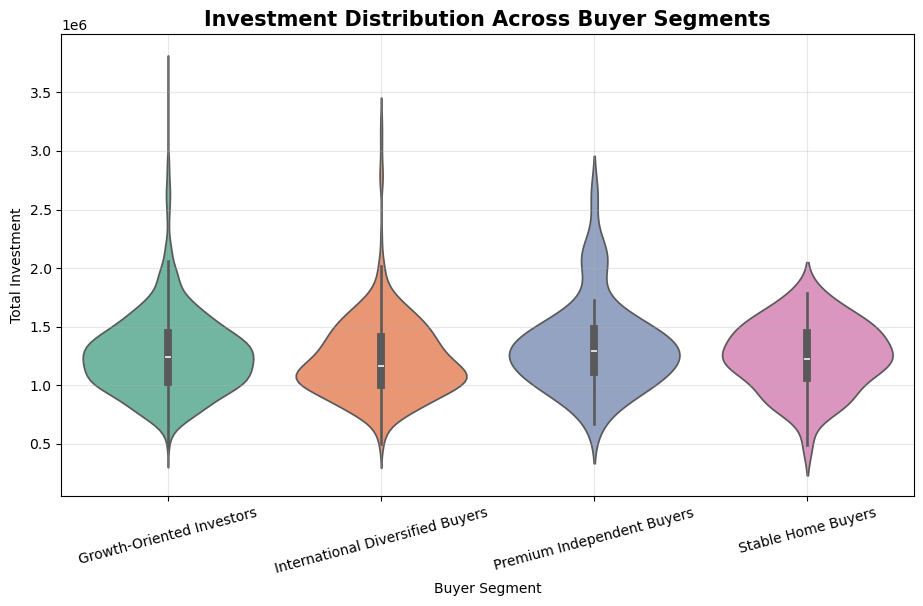

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11,6))

sns.violinplot(
    data=buyer_clustered,
    x="Buyer_Segment",
    y="total_investment",
    hue="Buyer_Segment",
    palette="Set2",
    legend=False
)

plt.xticks(rotation=15)
plt.title("Investment Distribution Across Buyer Segments",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Buyer Segment")
plt.ylabel("Total Investment")

plt.grid(alpha=0.3)

plt.show()

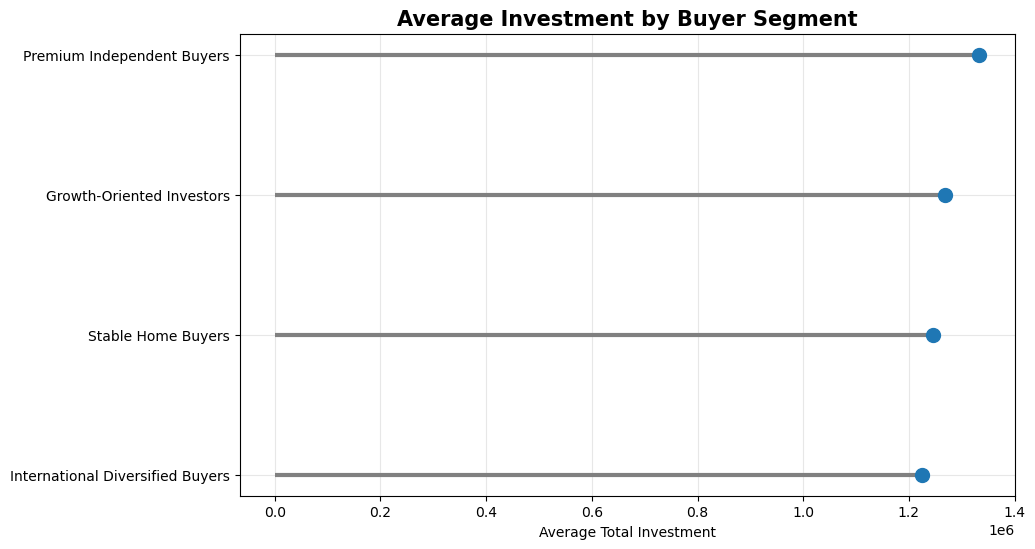

In [136]:
avg_inv = buyer_clustered.groupby("Buyer_Segment")["total_investment"].mean().sort_values()

plt.figure(figsize=(10,6))

plt.hlines(
    y=avg_inv.index,
    xmin=0,
    xmax=avg_inv.values,
    linewidth=3,
    color="gray"
)

plt.plot(
    avg_inv.values,
    avg_inv.index,
    "o",
    markersize=10,
    color="#1f77b4"
)

plt.title("Average Investment by Buyer Segment",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Average Total Investment")
plt.grid(alpha=0.3)

plt.show()

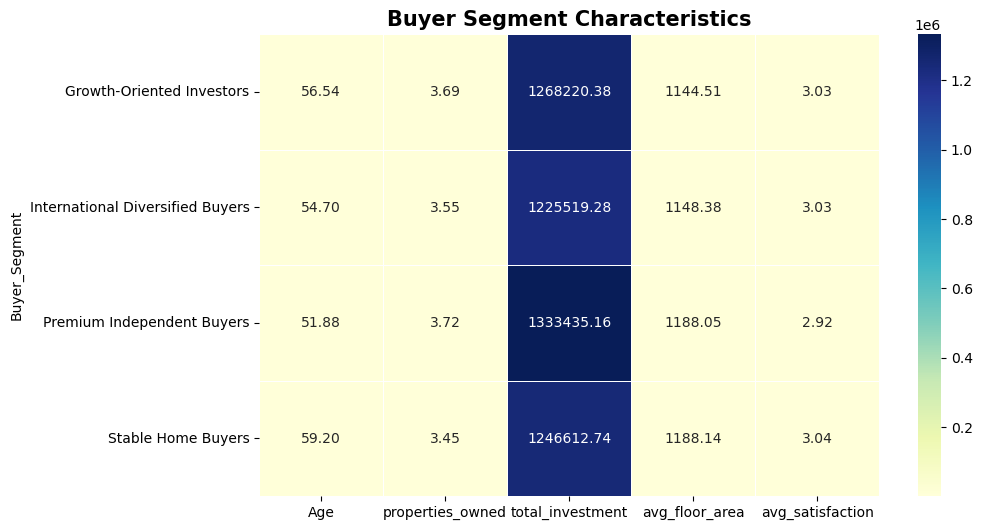

In [137]:
heatmap_data = buyer_clustered.groupby("Buyer_Segment")[[
    "Age",
    "properties_owned",
    "total_investment",
    "avg_floor_area",
    "avg_satisfaction"
]].mean()

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Buyer Segment Characteristics",
          fontsize=15,
          fontweight="bold")

plt.show()

In [138]:
buyer_clustered.to_csv(
    "buyer_market_intelligence.csv",
    index=False
)

print("Dataset exported successfully!")

Dataset exported successfully!


In [1]:
import os
print(os.getcwd())

C:\Users\user\Real Estate ML Intelligence


# Project Summary

This project successfully implemented a machine learning-based buyer segmentation and investment profiling framework for real estate market intelligence.

Key achievements include:

• Data cleaning and preprocessing of client and property datasets.
• Feature engineering to derive buyer investment characteristics.
• Exploratory Data Analysis using advanced visualizations.
• Buyer segmentation using K-Means clustering.
• Validation through Hierarchical Clustering.
• Investment profiling of buyer segments.
• Development of a recommendation engine to support strategic marketing and investment decisions.

The processed dataset has been exported for deployment in the Streamlit web application.